# Steam Games Multiclass Classification Model

This notebook builds a multiclass classification model to predict Steam game rating groups based on metadata, pricing, platform support, and category-related features.

The target variable is derived from `positive_rate` and grouped into four rating classes:

- `75-80`
- `81-85`
- `86-90`
- `>90`

This notebook is intended as the multiclass modeling part of the Steam game success prediction project.

## 1. Import Libraries

The libraries below are used for data manipulation, modeling, evaluation, and visualization.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

## 2. Load Dataset

The dataset used here is the modeling table prepared with BigQuery SQL.

In [3]:
drive.mount("/content/drive")

df_ml = pd.read_csv("/content/drive/MyDrive/steam_dataset_2025/steam_ml.csv")

df_ml.head()

Mounted at /content/drive


,appid,name,type,is_free,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,...,developers_clean,publishers_clean,categories_clean,total_reviews_clean,positive_reviews_clean,negative_reviews_clean,recommendations_total_clean,achievement_count_clean,has_metacritic,is_highly_rated
0,1101030,Noara: The Conspiracy,game,True,2021-11-14,NaN,NaN,NaN,NaN,NaN,...,ATYPIQUE studio,ATYPIQUE studio,"Co-op, Multi-player, Online Co-op, Online PvP,...",1,0,1,0,0,0,0
1,231467,COH 2 - Soviet Skin: (L) Three Color Leningrad...,dlc,False,2013-06-24,NaN,NaN,199.0,61.0,69.0,...,"Feral Interactive (Linux), Feral Interactive (...","Feral Interactive (Linux), Feral Interactive (...","Downloadable Content, Family Sharing, Multi-pl...",1,0,1,0,0,0,0
2,3399830,The Last of them,game,False,2025-04-11,NaN,NaN,499.0,499.0,0.0,...,Mohammad amin,Studio,"Family Sharing, Single-player",1,0,1,0,0,0,0
3,3383390,Tonya The Killer,game,False,2024-12-23,NaN,NaN,399.0,399.0,0.0,...,Gowi Game Studios,Gowi Game Studios,"Family Sharing, Single-player",1,0,1,0,0,0,0
4,1675070,SMETANKA,game,False,2021-07-13,NaN,NaN,199.0,55.0,72.0,...,Diamond Cats Studio,theNeko,"Family Sharing, Single-player, Steam Achievements",1,0,1,0,8,0,0


## 3. Data Overview

Before modeling, we inspect the dataset size, column types, and missing values.

In [4]:
print("Dataset shape:", df_ml.shape)

display(df_ml.head())
display(df_ml.info())
display(df_ml.describe(include="all").T.head(30))

Dataset shape: (117311, 48)


,appid,name,type,is_free,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,...,developers_clean,publishers_clean,categories_clean,total_reviews_clean,positive_reviews_clean,negative_reviews_clean,recommendations_total_clean,achievement_count_clean,has_metacritic,is_highly_rated
0,1101030,Noara: The Conspiracy,game,True,2021-11-14,NaN,NaN,NaN,NaN,NaN,...,ATYPIQUE studio,ATYPIQUE studio,"Co-op, Multi-player, Online Co-op, Online PvP,...",1,0,1,0,0,0,0
1,231467,COH 2 - Soviet Skin: (L) Three Color Leningrad...,dlc,False,2013-06-24,NaN,NaN,199.0,61.0,69.0,...,"Feral Interactive (Linux), Feral Interactive (...","Feral Interactive (Linux), Feral Interactive (...","Downloadable Content, Family Sharing, Multi-pl...",1,0,1,0,0,0,0
2,3399830,The Last of them,game,False,2025-04-11,NaN,NaN,499.0,499.0,0.0,...,Mohammad amin,Studio,"Family Sharing, Single-player",1,0,1,0,0,0,0
3,3383390,Tonya The Killer,game,False,2024-12-23,NaN,NaN,399.0,399.0,0.0,...,Gowi Game Studios,Gowi Game Studios,"Family Sharing, Single-player",1,0,1,0,0,0,0
4,1675070,SMETANKA,game,False,2021-07-13,NaN,NaN,199.0,55.0,72.0,...,Diamond Cats Studio,theNeko,"Family Sharing, Single-player, Steam Achievements",1,0,1,0,8,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117311 entries, 0 to 117310
Data columns (total 48 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   appid                        117311 non-null  int64  
 1   name                         117311 non-null  object 
 2   type                         117063 non-null  object 
 3   is_free                      117311 non-null  bool   
 4   release_date                 116826 non-null  object 
 5   metacritic_score             4454 non-null    float64
 6   recommendations_total        22445 non-null   float64
 7   mat_initial_price            110378 non-null  float64
 8   mat_final_price              110378 non-null  float64
 9   mat_discount_percent         110378 non-null  float64
 10  mat_supports_windows         117311 non-null  bool   
 11  mat_supports_mac             117311 non-null  bool   
 12  mat_supports_linux           117311 non-null  bool   
 13 

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,117311.0,NaN,NaN,NaN,1647462.783439,985969.31469,400.0,808255.0,1517202.0,2399175.0,3977550.0
name,117311,116765,Alone,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,117063,5,game,85529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_free,117311,2,False,112699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,116826,5140,2020-06-18,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metacritic_score,4454.0,NaN,NaN,NaN,73.861922,10.35737,6.0,68.0,76.0,81.0,97.0
recommendations_total,22445.0,NaN,NaN,NaN,4367.327512,34132.61626,101.0,174.0,368.0,1201.0,1835735.0
mat_initial_price,110378.0,NaN,NaN,NaN,28228.541593,976043.099446,50.0,299.0,599.0,1099.0,89900000.0
mat_final_price,110378.0,NaN,NaN,NaN,25614.137709,886595.453954,44.0,299.0,499.0,999.0,89100000.0
mat_discount_percent,110378.0,NaN,NaN,NaN,6.170577,19.086113,0.0,0.0,0.0,0.0,95.0


In [5]:
missing_values = (
    df_ml.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_values.head(20)

,missing_count
metacritic_score,112857
recommendations_total,94866
mat_achievement_count,65679
mat_initial_price,6933
mat_final_price,6933
mat_discount_percent,6933
price_usd,6933
publishers,5913
genres,3226
categories,3177


## 4. Data Filtering

Very high prices can behave as outliers and distort the model.  
The same filtering rule used in the binary model is applied here: games with `price_usd <= 100` are kept.

In [6]:
df_ml = df_ml[df_ml["price_usd"] <= 100].copy()

print("Filtered dataset shape:", df_ml.shape)

Filtered dataset shape: (109629, 48)


## 5. Create Multiclass Target

Only games with a `positive_rate >= 0.75` are included in this multiclass setup.  
The target groups are created from positive review rate intervals.

In [7]:
df_multi = df_ml[df_ml["positive_rate"] >= 0.75].copy()

bins = [0.75, 0.80, 0.85, 0.90, 1.00]
labels = ["75-80", "81-85", "86-90", ">90"]

df_multi["rating_group"] = pd.cut(
    df_multi["positive_rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_multi = df_multi.dropna(subset=["rating_group"]).copy()

df_multi["rating_group"].value_counts().sort_index()

,count
rating_group,
75-80,5828
81-85,2967
86-90,3989
>90,58114


In [8]:
le = LabelEncoder()

df_multi["rating_group_encoded"] = le.fit_transform(df_multi["rating_group"])

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
class_mapping

{'75-80': np.int64(0),
 '81-85': np.int64(1),
 '86-90': np.int64(2),
 '>90': np.int64(3)}

## 6. Feature Selection

Columns that directly leak the target or are identifiers are removed.  
The remaining features represent game metadata, pricing, platform support, and categorical information.

In [9]:
drop_cols = [
    # Target and leakage columns
    "rating_group",
    "rating_group_encoded",
    "is_highly_rated",
    "positive_rate",
    "positive_reviews",
    "negative_reviews",
    "total_reviews",
    "total_reviews_clean",
    "positive_reviews_clean",
    "negative_reviews_clean",

    # Review behavior columns that would not be available before reviews
    "avg_playtime_forever",
    "avg_playtime_at_review",
    "avg_weighted_vote_score",
    "total_votes_up",
    "total_votes_funny",
    "steam_purchase_reviews",
    "received_for_free_reviews",
    "early_access_reviews",

    # Identifiers / non-modeling columns
    "appid",
    "name",
    "release_date"
]

X_multi = df_multi.drop(columns=[col for col in drop_cols if col in df_multi.columns])
y_multi = df_multi["rating_group_encoded"]

print("Feature matrix shape:", X_multi.shape)
print("Target shape:", y_multi.shape)

Feature matrix shape: (70898, 29)
Target shape: (70898,)


In [10]:
X_multi.dtypes

,0
type,object
is_free,bool
metacritic_score,float64
recommendations_total,float64
mat_initial_price,float64
mat_final_price,float64
mat_discount_percent,float64
mat_supports_windows,bool
mat_supports_mac,bool
mat_supports_linux,bool


## 7. Train-Test Split

A stratified split is used to preserve the class distribution in both training and test sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=42,
    stratify=y_multi
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).sort_index())

X_train: (56718, 29)
X_test: (14180, 29)
y_train distribution:
rating_group_encoded
0    0.082196
1    0.041856
2    0.056261
3    0.819687
Name: proportion, dtype: float64


## 8. Missing Value Handling and Categorical Conversion

Numerical missing values are filled using simple train-based rules.  
Categorical columns are converted to the `category` dtype for LightGBM.

In [12]:
# Numeric imputations
if "metacritic_score" in X_train.columns:
    X_train["metacritic_score"] = X_train["metacritic_score"].fillna(0)
    X_test["metacritic_score"] = X_test["metacritic_score"].fillna(0)

if "release_year" in X_train.columns:
    median_year = X_train["release_year"].median()
    X_train["release_year"] = X_train["release_year"].fillna(median_year)
    X_test["release_year"] = X_test["release_year"].fillna(median_year)

if "price_usd" in X_train.columns:
    median_price = X_train["price_usd"].median()
    X_train["price_usd"] = X_train["price_usd"].fillna(median_price)
    X_test["price_usd"] = X_test["price_usd"].fillna(median_price)

# Categorical conversion
cat_cols = [
    "is_free",
    "mat_supports_windows",
    "mat_supports_mac",
    "mat_supports_linux",
    "price_type",
    "type_clean",
    "genres_clean",
    "developers_clean",
    "publishers_clean",
    "categories_clean",
    "has_metacritic"
]

for col in cat_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype("category")
        X_test[col] = X_test[col].astype("category")

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56718 entries, 92316 to 17259
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   type                         56716 non-null  object  
 1   is_free                      56718 non-null  category
 2   metacritic_score             56718 non-null  float64 
 3   recommendations_total        11230 non-null  float64 
 4   mat_initial_price            56718 non-null  float64 
 5   mat_final_price              56718 non-null  float64 
 6   mat_discount_percent         56718 non-null  float64 
 7   mat_supports_windows         56718 non-null  category
 8   mat_supports_mac             56718 non-null  category
 9   mat_supports_linux           56718 non-null  category
 10  mat_achievement_count        25890 non-null  float64 
 11  genres                       54653 non-null  object  
 12  developers                   56585 non-null  object  
 13  pu

## 9. Baseline LightGBM Multiclass Model

The first model is a baseline LightGBM multiclass classifier.

In [13]:
lgbm_base = LGBMClassifier(
    objective="multiclass",
    num_class=len(le.classes_),
    metric="multi_logloss",
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1
)

problematic_object_cols = ['type', 'genres', 'developers', 'publishers', 'categories']
for col in problematic_object_cols:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])

lgbm_base.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="multi_logloss",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10061
[LightGBM] [Info] Number of data points in the train set: 56718, number of used features: 17
[LightGBM] [Info] Start training from score -2.498647
[LightGBM] [Info] Start training from score -3.173515
[LightGBM] [Info] Start training from score -2.877757
[LightGBM] [Info] Start training from score -0.198833
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	valid_0's multi_logloss: 0.607482


LGBMClassifier(learning_rate=0.05, metric='multi_logloss', n_estimators=500,
               n_jobs=-1, num_class=4, objective='multiclass', random_state=42)

## 10. Baseline Model Evaluation

The model is evaluated using accuracy, weighted precision, weighted recall, weighted F1-score, and a classification report.

In [14]:
y_pred_base = lgbm_base.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_base))
print("Precision:", precision_score(y_test, y_pred_base, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_base, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_base, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

Accuracy : 0.8214386459802538
Precision: 0.7948115869751677
Recall   : 0.8214386459802538
F1 Score : 0.7429932418763828

Classification Report:
              precision    recall  f1-score   support

       75-80       0.79      0.02      0.04      1166
       81-85       0.00      0.00      0.00       593
       86-90       1.00      0.01      0.01       798
         >90       0.82      1.00      0.90     11623

    accuracy                           0.82     14180
   macro avg       0.65      0.26      0.24     14180
weighted avg       0.79      0.82      0.74     14180



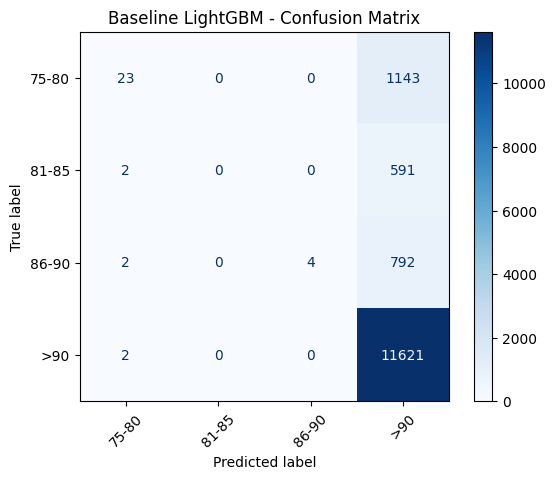

In [15]:
cm_base = confusion_matrix(y_test, y_pred_base)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=le.classes_
)

disp.plot(values_format="d", xticks_rotation=45,  cmap='Blues')
plt.title("Baseline LightGBM - Confusion Matrix")
plt.show()

## 11. LightGBM with Class Weights

Because rating groups may be imbalanced, class weights are calculated and passed to LightGBM.

In [16]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
class_weights

{np.int64(0): np.float64(3.0415057915057915),
 np.int64(1): np.float64(5.972830665543387),
 np.int64(2): np.float64(4.44359135067377),
 np.int64(3): np.float64(0.3049945150674324)}

In [17]:
lgbm_weighted = LGBMClassifier(
    objective="multiclass",
    num_class=len(le.classes_),
    class_weight=class_weights,
    metric="multi_logloss",
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1
)

lgbm_weighted.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="multi_logloss",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10061
[LightGBM] [Info] Number of data points in the train set: 56718, number of used features: 17
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 1.0844
[200]	valid_0's multi_logloss: 1.05264
[300]	valid_0's multi_logloss: 1.03215
[400]	valid_0's multi_logloss: 1.01587
[500]	valid_0's multi_logloss: 1.00292
Did not 

LGBMClassifier(class_weight={np.int64(0): np.float64(3.0415057915057915),
                             np.int64(1): np.float64(5.972830665543387),
                             np.int64(2): np.float64(4.44359135067377),
                             np.int64(3): np.float64(0.3049945150674324)},
               learning_rate=0.05, metric='multi_logloss', n_estimators=500,
               n_jobs=-1, num_class=4, objective='multiclass', random_state=42)

## 12. Weighted Model Evaluation

In [18]:
y_pred_weighted = lgbm_weighted.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_weighted))
print("Precision:", precision_score(y_test, y_pred_weighted, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_weighted, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_weighted, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted, target_names=le.classes_))

Accuracy : 0.6031734837799718
Precision: 0.7504348268638099
Recall   : 0.6031734837799718
F1 Score : 0.660743264262317

Classification Report:
              precision    recall  f1-score   support

       75-80       0.14      0.33      0.20      1166
       81-85       0.09      0.16      0.11       593
       86-90       0.13      0.24      0.17       798
         >90       0.89      0.68      0.77     11623

    accuracy                           0.60     14180
   macro avg       0.31      0.35      0.31     14180
weighted avg       0.75      0.60      0.66     14180



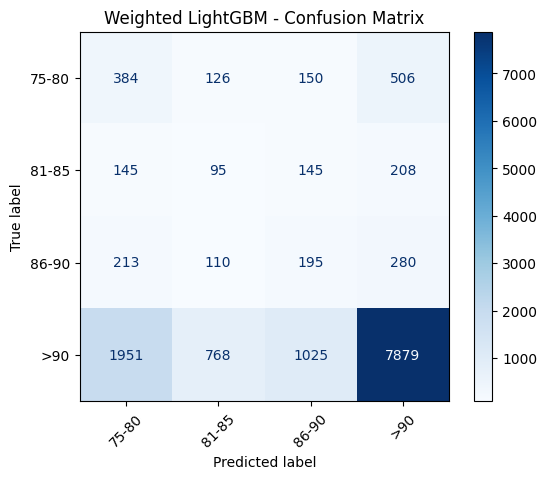

In [19]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=le.classes_
)

disp.plot(values_format="d", xticks_rotation=45,  cmap='Blues')
plt.title("Weighted LightGBM - Confusion Matrix")
plt.show()

## 13. Feature Importance

Feature importance helps identify which variables contribute most to the multiclass classification model.

In [20]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_weighted.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
17,genres_clean,9420
20,categories_clean,8233
9,mat_achievement_count,7416
19,publishers_clean,6837
10,release_year,6029
18,developers_clean,5085
2,recommendations_total,4938
3,mat_initial_price,4575
4,mat_final_price,4548
5,mat_discount_percent,868


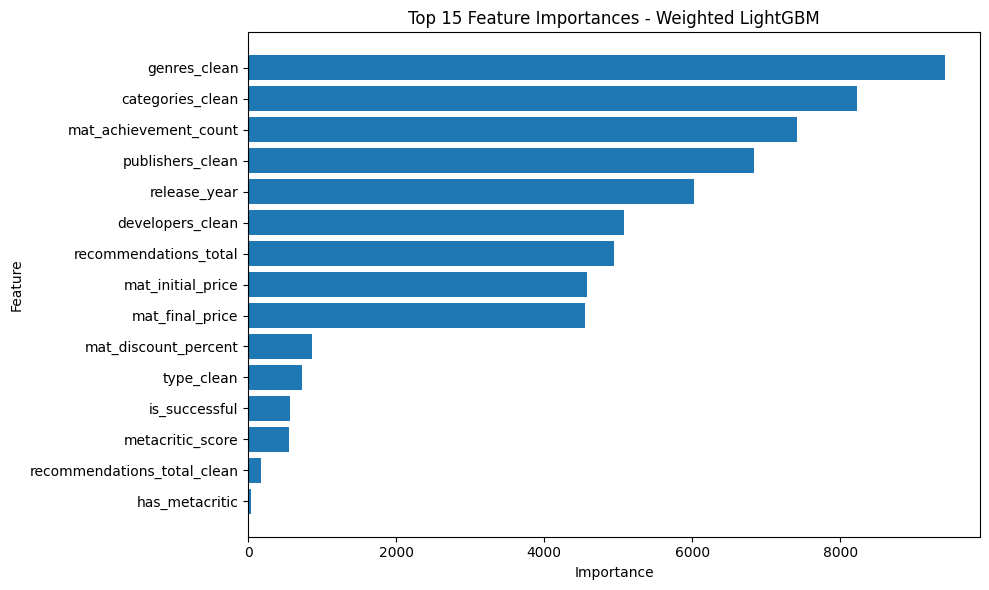

In [21]:
top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances - Weighted LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 14. Optional: CatBoost Multiclass Model

CatBoost can handle categorical variables effectively.  
This section is optional and may take longer to run.

In [22]:
# Install CatBoost in Colab if needed
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [23]:
from catboost import CatBoostClassifier

for col in ['developers_clean', 'publishers_clean']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(object).fillna("Unknown").astype("category")
        X_test[col] = X_test[col].astype(object).fillna("Unknown").astype("category")

cat_feature_indices = [
    X_train.columns.get_loc(col)
    for col in cat_cols
    if col in X_train.columns
]

cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.7389859	test: 0.7384482	best: 0.7384482 (0)	total: 656ms	remaining: 5m 27s
100:	learn: 0.7420667	test: 0.7421772	best: 0.7421772 (100)	total: 1m 9s	remaining: 4m 35s
200:	learn: 0.7486978	test: 0.7448926	best: 0.7450258 (187)	total: 1m 54s	remaining: 2m 50s
300:	learn: 0.7529442	test: 0.7468011	best: 0.7469590 (292)	total: 2m 46s	remaining: 1m 50s
400:	learn: 0.7553301	test: 0.7487691	best: 0.7487691 (400)	total: 3m 36s	remaining: 53.5s
499:	learn: 0.7581158	test: 0.7486680	best: 0.7488333 (492)	total: 4m 22s	remaining: 0us

bestTest = 0.7488333291
bestIteration = 492

Shrink model to first 493 iterations.


CatBoostClassifier(depth=6, eval_metric='TotalF1', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

## 15. CatBoost Evaluation

In [24]:
y_pred_cat = cat_model.predict(X_test).flatten()

print("Accuracy :", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_cat, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_cat, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat, target_names=le.classes_))

Accuracy : 0.8213681241184767
Precision: 0.7536653090727262
Recall   : 0.8213681241184767
F1 Score : 0.7488333290567637

Classification Report:
              precision    recall  f1-score   support

       75-80       0.53      0.04      0.07      1166
       81-85       0.37      0.01      0.02       593
       86-90       0.32      0.02      0.04       798
         >90       0.83      1.00      0.90     11623

    accuracy                           0.82     14180
   macro avg       0.51      0.27      0.26     14180
weighted avg       0.75      0.82      0.75     14180



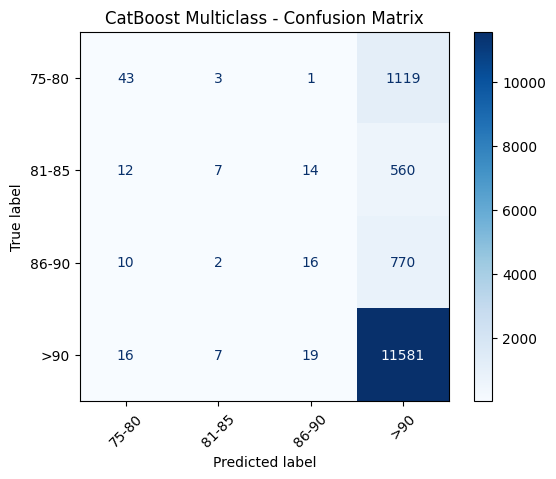

In [25]:
cm_cat = confusion_matrix(y_test, y_pred_cat)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cat,
    display_labels=le.classes_
)

disp.plot(values_format="d", xticks_rotation=45,  cmap='Blues')
plt.title("CatBoost Multiclass - Confusion Matrix")
plt.show()

In [26]:
catboost_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

catboost_importance_df.head(15)

,feature,importance
10,release_year,15.572452
21,recommendations_total_clean,10.615998
13,is_successful,9.943577
2,recommendations_total,9.846133
20,categories_clean,9.728451
19,publishers_clean,9.522360
17,genres_clean,9.364006
18,developers_clean,7.664702
16,type_clean,6.063391
3,mat_initial_price,2.448646


## 16. Optimized CatBoost Multiclass Model with Optuna

This section tunes CatBoost hyperparameters using Optuna.  
The optimization objective is weighted F1-score, which is more suitable than accuracy when class distributions are imbalanced.

> Note: This section may take longer to run. You can reduce `n_trials` if needed.


In [27]:
from sklearn.model_selection import train_test_split

X_train_opt, X_valid, y_train_opt, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [28]:
# Install Optuna in Colab if needed
!pip -q install optuna

import optuna
from sklearn.metrics import f1_score


def objective_catboost_multiclass(trial):
    params = {
        "loss_function": "MultiClass",
        "eval_metric": "TotalF1",
        "iterations": trial.suggest_int("iterations", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_seed": 42,
        "verbose": 0,
        "auto_class_weights": "Balanced",
        "early_stopping_rounds": 50
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_train_opt,
        y_train_opt,
        cat_features=cat_feature_indices,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    y_pred_valid = model.predict(X_valid).flatten()
    return f1_score(y_valid, y_pred_valid, average="weighted")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.6 MB/s eta 0:00:00


In [29]:
study_catboost_multi = optuna.create_study(
    direction="maximize",
    study_name="CatBoost_Multiclass_Optimization"
)

study_catboost_multi.optimize(
    objective_catboost_multiclass,
    n_trials=30,
    show_progress_bar=True
)

print("Best weighted F1:", study_catboost_multi.best_value)
print("Best parameters:")
for key, value in study_catboost_multi.best_params.items():
    print(f"{key}: {value}")


[I 2026-06-28 20:19:14,330] A new study created in memory with name: CatBoost_Multiclass_Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-28 20:20:47,380] Trial 0 finished with value: 0.6572680277211641 and parameters: {'iterations': 1098, 'learning_rate': 0.013563565169062299, 'depth': 4, 'l2_leaf_reg': 1.0783421167437413}. Best is trial 0 with value: 0.6572680277211641.
[I 2026-06-28 20:22:09,088] Trial 1 finished with value: 0.6574671062741994 and parameters: {'iterations': 510, 'learning_rate': 0.024701181725969763, 'depth': 5, 'l2_leaf_reg': 1.1667980815735273}. Best is trial 1 with value: 0.6574671062741994.
[I 2026-06-28 20:23:47,193] Trial 2 finished with value: 0.6557941113415509 and parameters: {'iterations': 1008, 'learning_rate': 0.07875046416088488, 'depth': 8, 'l2_leaf_reg': 4.707557151486225}. Best is trial 1 with value: 0.6574671062741994.
[I 2026-06-28 20:25:26,765] Trial 3 finished with value: 0.661306315398502 and parameters: {'iterations': 615, 'learning_rate': 0.01969423887771993, 'depth': 5, 'l2_leaf_reg': 4.998785675445105}. Best is trial 3 with value: 0.661306315398502.
[I 2026-06-28 20

## 17. Retrain Optimized CatBoost Model

After Optuna finds the best hyperparameters, the final CatBoost model is retrained using those parameters.


In [30]:
best_params_catboost_multi = study_catboost_multi.best_params

best_catboost_model_multi = CatBoostClassifier(
    **best_params_catboost_multi,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100
)

best_catboost_model_multi.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test, y_test),
    use_best_model=True
)

print("Optimized CatBoost multiclass model trained successfully.")


0:	learn: 0.3174025	test: 0.3096358	best: 0.3096358 (0)	total: 954ms	remaining: 9m 34s
100:	learn: 0.4175960	test: 0.3354749	best: 0.3373737 (81)	total: 2m 7s	remaining: 10m 34s
200:	learn: 0.4596715	test: 0.3446804	best: 0.3466762 (181)	total: 3m 35s	remaining: 7m 11s
300:	learn: 0.4928715	test: 0.3485032	best: 0.3485032 (300)	total: 5m	remaining: 5m 1s
400:	learn: 0.5244362	test: 0.3456342	best: 0.3498284 (366)	total: 6m 32s	remaining: 3m 17s
500:	learn: 0.5583869	test: 0.3535187	best: 0.3549945 (468)	total: 8m 11s	remaining: 1m 40s
600:	learn: 0.5861176	test: 0.3520857	best: 0.3563658 (526)	total: 9m 51s	remaining: 1.97s
602:	learn: 0.5863654	test: 0.3521982	best: 0.3563658 (526)	total: 9m 53s	remaining: 0us

bestTest = 0.3563658205
bestIteration = 526

Shrink model to first 527 iterations.
Optimized CatBoost multiclass model trained successfully.


## 18. Optimized CatBoost Evaluation

The optimized CatBoost model is evaluated with the same metrics used for the previous models.


In [37]:
y_pred_cat_opt = best_catboost_model_multi.predict(X_test).flatten()

print("Accuracy :", accuracy_score(y_test, y_pred_cat_opt))
print("Precision:", precision_score(y_test, y_pred_cat_opt, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_cat_opt, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_cat_opt, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat_opt, target_names=le.classes_))

Accuracy : 0.5804654442877292
Precision: 0.7644784405916054
Recall   : 0.5804654442877292
F1 Score : 0.6471850644339042

Classification Report:
              precision    recall  f1-score   support

       75-80       0.13      0.41      0.20      1166
       81-85       0.13      0.22      0.16       593
       86-90       0.14      0.23      0.17       798
         >90       0.90      0.64      0.75     11623

    accuracy                           0.58     14180
   macro avg       0.33      0.37      0.32     14180
weighted avg       0.76      0.58      0.65     14180



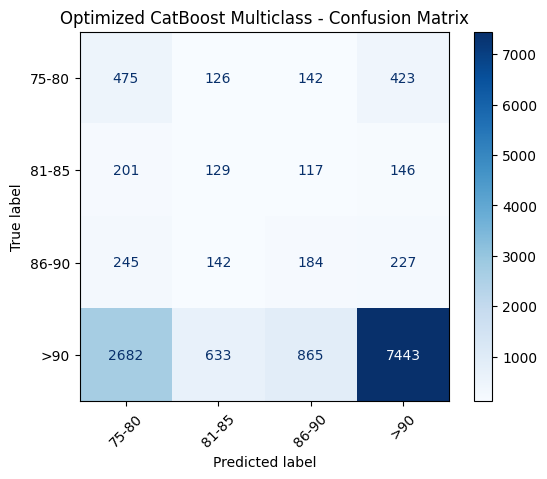

In [38]:
cm_cat_opt = confusion_matrix(y_test, y_pred_cat_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cat_opt,
    display_labels=le.classes_
)

disp.plot(values_format="d", xticks_rotation=45, cmap='Blues')
plt.title("Optimized CatBoost Multiclass - Confusion Matrix")
plt.show()


In [39]:
catboost_opt_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_catboost_model_multi.get_feature_importance()
}).sort_values("importance", ascending=False)

catboost_opt_importance_df.head(15)


,feature,importance
17,genres_clean,14.738723
20,categories_clean,13.598510
19,publishers_clean,12.057555
10,release_year,11.921787
18,developers_clean,10.115642
16,type_clean,8.857491
21,recommendations_total_clean,6.449619
2,recommendations_total,5.863614
13,is_successful,4.828057
3,mat_initial_price,2.586123


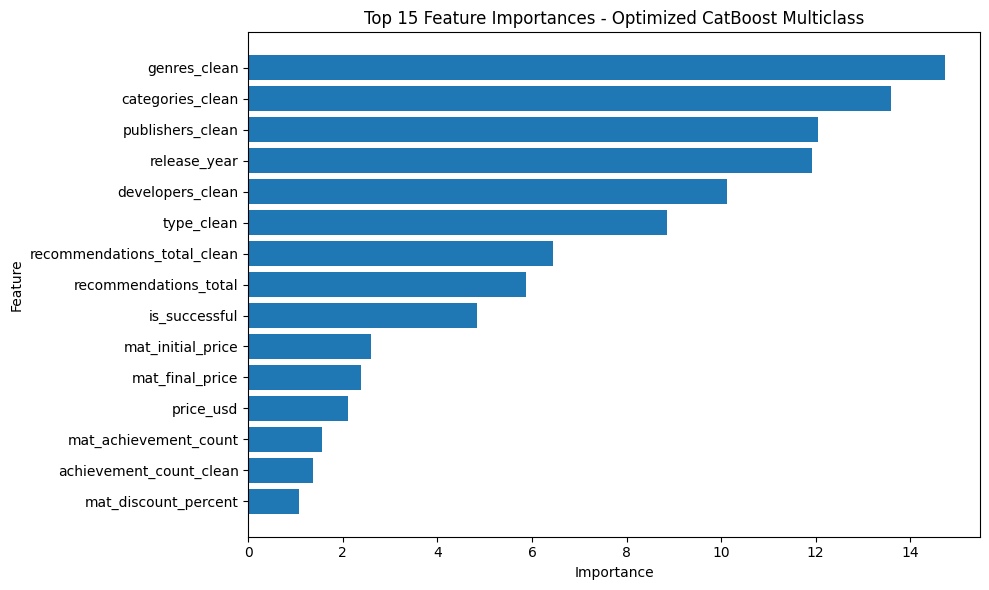

In [40]:
top_catboost_features = catboost_opt_importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_catboost_features["feature"], top_catboost_features["importance"])
plt.title("Top 15 Feature Importances - Optimized CatBoost Multiclass")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 19. Model Comparison

This section summarizes the main performance metrics of all multiclass models.


In [41]:
results = pd.DataFrame([
    {
        "model": "LightGBM Baseline",
        "accuracy": accuracy_score(y_test, y_pred_base),
        "precision_weighted": precision_score(y_test, y_pred_base, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred_base, average="weighted"),
        "f1_weighted": f1_score(y_test, y_pred_base, average="weighted")
    },
    {
        "model": "LightGBM Weighted",
        "accuracy": accuracy_score(y_test, y_pred_weighted),
        "precision_weighted": precision_score(y_test, y_pred_weighted, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred_weighted, average="weighted"),
        "f1_weighted": f1_score(y_test, y_pred_weighted, average="weighted")
    },
    {
        "model": "CatBoost Multiclass",
        "accuracy": accuracy_score(y_test, y_pred_cat),
        "precision_weighted": precision_score(y_test, y_pred_cat, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred_cat, average="weighted"),
        "f1_weighted": f1_score(y_test, y_pred_cat, average="weighted")
    },
    {
        "model": "Optimized CatBoost Multiclass",
        "accuracy": accuracy_score(y_test, y_pred_cat_opt),
        "precision_weighted": precision_score(y_test, y_pred_cat_opt, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred_cat_opt, average="weighted"),
        "f1_weighted": f1_score(y_test, y_pred_cat_opt, average="weighted")
    }
])

results.sort_values("f1_weighted", ascending=False)


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
2,CatBoost Multiclass,0.821368,0.753665,0.821368,0.748833
0,LightGBM Baseline,0.821439,0.794812,0.821439,0.742993
1,LightGBM Weighted,0.603173,0.750435,0.603173,0.660743
3,Optimized CatBoost Multiclass,0.580465,0.764478,0.580465,0.647185


In [42]:
print(study_catboost_multi.best_value)

print(study_catboost_multi.best_params)

0.668831122207984
{'iterations': 603, 'learning_rate': 0.03009911372330126, 'depth': 8, 'l2_leaf_reg': 8.277717243040245}


## 20. Conclusion

This notebook explored multiclass classification for Steam game rating groups.

Key points:

- The target was created from `positive_rate` intervals.
- Target leakage columns such as `positive_rate`, review counts, and review-based metrics were excluded from the feature matrix.
- LightGBM was used as the baseline multiclass model.
- A weighted LightGBM model was tested to address class imbalance.
- CatBoost was added because it can handle categorical variables effectively.
- Optimized CatBoost was tuned with Optuna and compared against the baseline models.

The final model choice should be based mainly on weighted F1-score and class-level performance in the classification report.
